In [ ]:
import torch

In [ ]:
print("Is GPU available?:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    memory = torch.cuda.get_device_properties(0).total_memory
    print("GPU memory:", round(memory / 1024**3, 1), "GB")
else:
    print("No GPU connected. Check the runtime settings.")

Is GPU available?: True
GPU name: Tesla T4
GPU memory: 14.6 GB


In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(round((torch.cuda.get_device_properties(0).total_memory) / 1024**3, 1))

True
Tesla T4
14.6


In [ ]:
%pip install -q -U transformers accelerate huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 55.6 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from transformers import (
    PaliGemmaProcessor,
    PaliGemmaForConditionalGeneration,
)
from transformers.image_utils import load_image

model_id = "google/paligemma2-10b-mix-448"


model = PaliGemmaForConditionalGeneration.from_pretrained(model_id, torch_dtype=torch.bfloat16, device_map="auto").eval()
processor = PaliGemmaProcessor.from_pretrained(model_id)


config.json:   0%|          | 0.00/1.36k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/92.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/903 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/243k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 34.6MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

In [ ]:
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"
image = load_image(url)

prompt = "describe en"
model_inputs = processor(text=prompt, images=image, return_tensors="pt").to(torch.bfloat16).to(model.device)
input_len = model_inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**model_inputs, max_new_tokens=100, do_sample=False)
    generation = generation[0][input_len:]
    decoded = processor.decode(generation, skip_special_tokens=True)
    print(decoded)

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


A small, vintage blue car is parked in front of a yellow building. The car has a black tire with a silver rim on the front and rear wheels. The car's windows are open, and the headlights are on. The car is parked on a brick road, and the sidewalk is concrete. The building has a brown door and a light blue wall. The tree above the building is tall and slender. The front tire on the car is worn, and the back tire is new. The


In [ ]:
questions = [
    ("en", "What color is the car?"),
    ("tr", "Araba ne renk?")
]

for language, question in questions:
    prompt = f"<image>answer {language} {question}"

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    ).to(model.device, dtype=model.dtype)

    input_length = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False
        )

    answer = processor.decode(
        output_ids[0][input_length:],
        skip_special_tokens=True
    )

    print(f"{language} sorusu: {question}")
    print(f"{language} cevabı: {answer}\n")

en sorusu: What color is the car?
en cevabı: blue

tr sorusu: Araba ne renk?
tr cevabı: aqua



In [ ]:
questions = [
    ("en", "What vehicle is in the image?"),
    ("tr", "Görselde hangi araç var?")
]
for language, question in questions:
    prompt = f"<image>answer {language} {question}"

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    ).to(model.device, dtype=model.dtype)

    input_length = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False
        )

    answer = processor.decode(
        output_ids[0][input_length:],
        skip_special_tokens=True
    )

    print(f"{language} sorusu: {question}")
    print(f"{language} cevabı: {answer}\n")

en sorusu: What vehicle is in the image?
en cevabı: car

tr sorusu: Görselde hangi araç var?
tr cevabı: Resimde bir Volkswagen Beetle gösterilmektedir.



Saving fiş.jpg to fiş.jpg


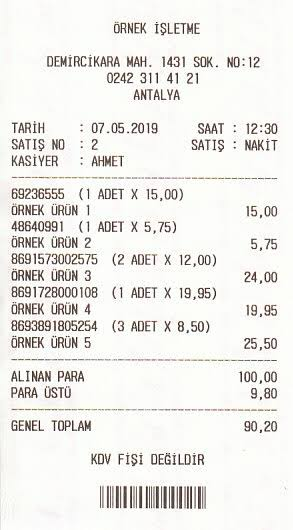

In [ ]:
from google.colab import files
from PIL import Image

uploaded = files.upload()
filename = next(iter(uploaded))

receipt_image = Image.open(filename).convert("RGB")
display(receipt_image)

In [ ]:
questions = [
    ("en", "What is the grand total on the receipt?"),
    ("tr", "Fişteki genel toplam tutarı nedir?")
]

for language, question in questions:
    inputs = processor(
        text=f"answer {language} {question}",
        images=receipt_image,
        return_tensors="pt"
    ).to(model.device, dtype=model.dtype)

    input_length = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False
        )

    answer = processor.decode(
        output_ids[0][input_length:],
        skip_special_tokens=True
    )

    print(f"{language} sorusu: {question}")
    print(f"{language} cevabı: {answer}\n")

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


en sorusu: What is the grand total on the receipt?
en cevabı: 90.20

tr sorusu: Fişteki genel toplam tutarı nedir?
tr cevabı: 90,20



In [ ]:
questions = [
    ("en", "What is the cashier's name on the receipt?"),
    ("tr", "Fişteki kasiyerin adı nedir?")
]
for language, question in questions:
    inputs = processor(
        text=f"answer {language} {question}",
        images=receipt_image,
        return_tensors="pt"
    ).to(model.device, dtype=model.dtype)

    input_length = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False
        )

    answer = processor.decode(
        output_ids[0][input_length:],
        skip_special_tokens=True
    )

    print(f"{language} sorusu: {question}")
    print(f"{language} cevabı: {answer}\n")

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


en sorusu: What is the cashier's name on the receipt?
en cevabı: ahmet

tr sorusu: Fişteki kasiyerin adı nedir?
tr cevabı: Ahmet



Saving sofra.jpg to sofra.jpg


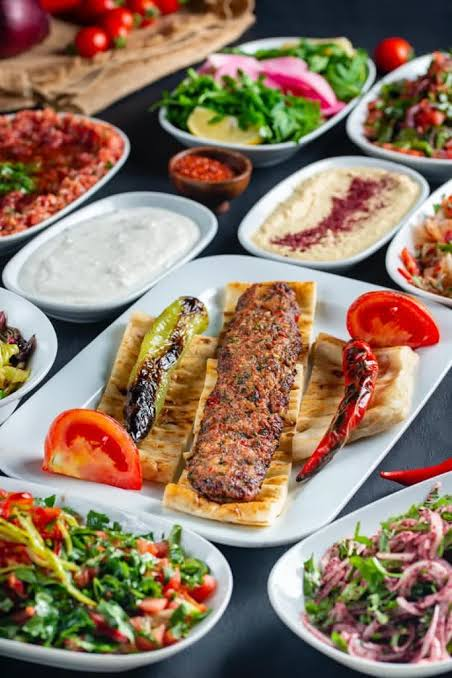

In [ ]:
from google.colab import files
from PIL import Image

uploaded = files.upload()
filename = next(iter(uploaded))

receipt_image = Image.open(filename).convert("RGB")
display(receipt_image)

In [ ]:
questions = [
    ("en", "On the central plate, what color is the pepper to the left of the kebab from the viewer's perspective?"),
    ("tr", "Ortadaki tabakta, bize göre kebabın solundaki biber ne renk?")
]
for language, question in questions:
    inputs = processor(
        text=f"answer {language} {question}",
        images=receipt_image,
        return_tensors="pt"
    ).to(model.device, dtype=model.dtype)

    input_length = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False
        )

    answer = processor.decode(
        output_ids[0][input_length:],
        skip_special_tokens=True
    )

    print(f"{language} sorusu: {question}")
    print(f"{language} cevabı: {answer}\n")

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


en sorusu: On the central plate, what color is the pepper to the left of the kebab from the viewer's perspective?
en cevabı: green

tr sorusu: Ortadaki tabakta, bize göre kebabın solundaki biber ne renk?
tr cevabı: Yeşil.



In [ ]:
questions = [
    ("en", "How many peppers are on the central plate?"),
    ("tr", "Ortadaki tabakta kaç biber var?")
]
for language, question in questions:
    inputs = processor(
        text=f"answer {language} {question}",
        images=receipt_image,
        return_tensors="pt"
    ).to(model.device, dtype=model.dtype)

    input_length = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False
        )

    answer = processor.decode(
        output_ids[0][input_length:],
        skip_special_tokens=True
    )

    print(f"{language} sorusu: {question}")
    print(f"{language} cevabı: {answer}\n")

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


en sorusu: How many peppers are on the central plate?
en cevabı: 2

tr sorusu: Ortadaki tabakta kaç biber var?
tr cevabı: Iki.

